# 🌳 The Simpsons — Árbol de Clasificación + Regresión Logística

**Tarea:** Clasificación binaria  
**Variable objetivo:** `rating_alto` (1 si imdb_rating ≥ 7.5, 0 si no)  
**Predictores:** `viewers_millions`, `season`, `duration_min`, `number_in_season`  
**Splits:** 80/20 · 70/30 · 60/40  

---

## 0. Imports y configuración

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve
)
from sklearn.preprocessing import StandardScaler
from config.database import engine

os.makedirs("../../data/graficas", exist_ok=True)
GRAFICAS = "../../data/graficas"

plt.rcParams.update({"figure.figsize": (12, 5), "axes.grid": True, "grid.alpha": 0.3})
sns.set_theme(style="whitegrid", palette="muted")
print("✅ Imports OK")

✅ Imports OK


## 1. Carga y preparación de datos

In [2]:
df = pd.read_sql("""
    SELECT episode_id, viewers_millions, imdb_rating,
           duration_min, season, number_in_season
    FROM fact_ratings
    ORDER BY episode_id
""", engine)

# Variable objetivo binaria usando la MEDIANA como umbral (garantiza balance)
UMBRAL = df["imdb_rating"].median()
df["rating_alto"] = (df["imdb_rating"] >= UMBRAL).astype(int)

print(f"Total registros: {len(df)}")
print(f"Umbral usado (mediana): {UMBRAL:.4f}")
print(f"\nDistribución de clases:")
print(df["rating_alto"].value_counts().rename({0: 'Rating bajo (0)', 1: 'Rating alto (1)'}))
print(f"\nBalance: {df['rating_alto'].mean()*100:.1f}% episodios con rating alto")

df.head()

Total registros: 768
Umbral usado (mediana): 0.4872

Distribución de clases:
rating_alto
Rating alto (1)    415
Rating bajo (0)    353
Name: count, dtype: int64

Balance: 54.0% episodios con rating alto


,episode_id,viewers_millions,imdb_rating,duration_min,season,number_in_season,rating_alto
0,1,0.904716,0.461538,0.0,0.0,0.000000,0
1,2,0.818415,0.820513,0.0,0.0,0.041667,1
2,3,0.933269,0.846154,0.0,0.0,0.083333,1
3,4,0.945460,0.794872,1.0,0.0,0.125000,1
4,5,0.760026,0.641026,0.0,0.0,0.166667,1


In [3]:
FEATURES = ["viewers_millions", "season", "duration_min", "number_in_season"]
TARGET   = "rating_alto"

df_model = df[FEATURES + [TARGET]].dropna()
X = df_model[FEATURES]
y = df_model[TARGET]

# Escalar para regresión logística
scaler = StandardScaler()

print(f"Registros para modelado: {len(df_model)}")

Registros para modelado: 768


## 2. Función de métricas de clasificación

In [4]:
def metricas_clasificacion(y_true, y_pred, y_prob, nombre_split, modelo):
    return {
        "Modelo":     modelo,
        "Split":      nombre_split,
        "Accuracy":   round(accuracy_score(y_true, y_pred), 4),
        "Precision":  round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall":     round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1":         round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC-AUC":    round(roc_auc_score(y_true, y_prob), 4),
    }

resultados = []

## 3. Split 1 — 80/20

In [5]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

X_train1_sc = scaler.fit_transform(X_train1)
X_test1_sc  = scaler.transform(X_test1)

# ── Árbol de clasificación ────────────────────────────────────────────────────
arbol1 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=15, min_samples_split=20, class_weight="balanced", random_state=42)
arbol1.fit(X_train1, y_train1)
pred_arbol1 = arbol1.predict(X_test1)
prob_arbol1 = arbol1.predict_proba(X_test1)[:, 1]

# ── Regresión logística ───────────────────────────────────────────────────────
logit1 = LogisticRegression(max_iter=1000, random_state=42)
logit1.fit(X_train1_sc, y_train1)
pred_logit1 = logit1.predict(X_test1_sc)
prob_logit1 = logit1.predict_proba(X_test1_sc)[:, 1]

resultados.append(metricas_clasificacion(y_test1, pred_arbol1, prob_arbol1, "80/20", "Árbol"))
resultados.append(metricas_clasificacion(y_test1, pred_logit1, prob_logit1, "80/20", "Reg. Logística"))

print("=== Split 80/20 ===")
print("\n--- Árbol de Clasificación ---")
print(classification_report(y_test1, pred_arbol1,
      target_names=['Rating bajo', 'Rating alto']))
print("\n--- Regresión Logística ---")
print(classification_report(y_test1, pred_logit1,
      target_names=['Rating bajo', 'Rating alto']))

=== Split 80/20 ===

--- Árbol de Clasificación ---
              precision    recall  f1-score   support

 Rating bajo       0.62      0.75      0.68        71
 Rating alto       0.74      0.61      0.67        83

    accuracy                           0.68       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.69      0.68      0.67       154


--- Regresión Logística ---
              precision    recall  f1-score   support

 Rating bajo       0.68      0.68      0.68        71
 Rating alto       0.72      0.72      0.72        83

    accuracy                           0.70       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.70      0.70      0.70       154



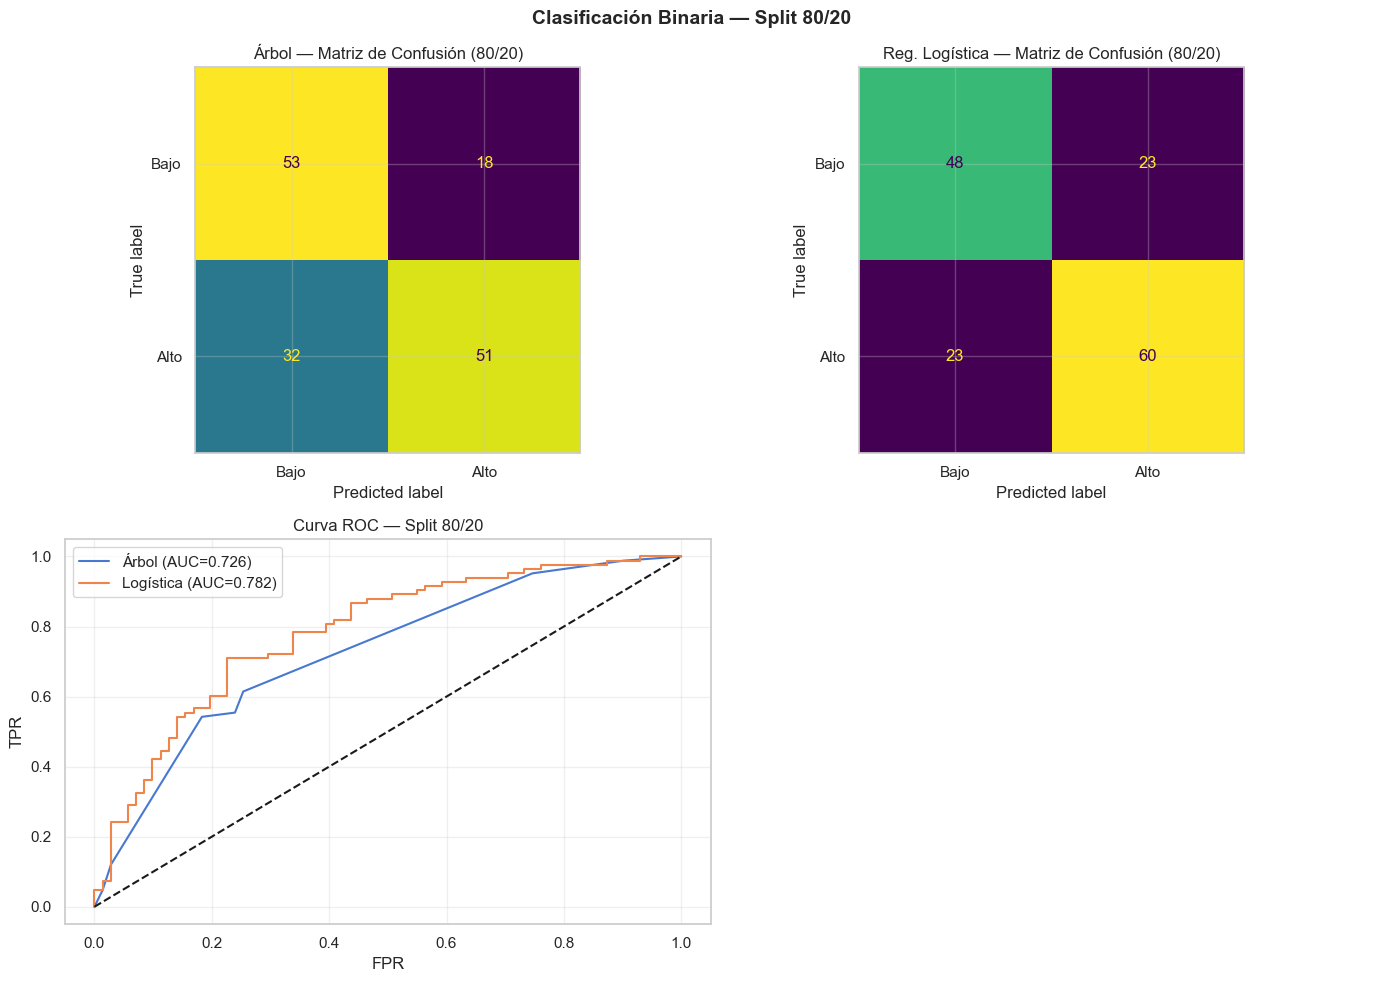

In [6]:
# Matrices de confusión y curvas ROC — Split 80/20
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ConfusionMatrixDisplay(confusion_matrix(y_test1, pred_arbol1),
    display_labels=['Bajo', 'Alto']).plot(ax=axes[0,0], colorbar=False)
axes[0,0].set_title('Árbol — Matriz de Confusión (80/20)')

ConfusionMatrixDisplay(confusion_matrix(y_test1, pred_logit1),
    display_labels=['Bajo', 'Alto']).plot(ax=axes[0,1], colorbar=False)
axes[0,1].set_title('Reg. Logística — Matriz de Confusión (80/20)')

fpr_a, tpr_a, _ = roc_curve(y_test1, prob_arbol1)
fpr_l, tpr_l, _ = roc_curve(y_test1, prob_logit1)
axes[1,0].plot(fpr_a, tpr_a, label=f"Árbol (AUC={roc_auc_score(y_test1, prob_arbol1):.3f})")
axes[1,0].plot(fpr_l, tpr_l, label=f"Logística (AUC={roc_auc_score(y_test1, prob_logit1):.3f})")
axes[1,0].plot([0,1],[0,1],'k--')
axes[1,0].set_xlabel('FPR'); axes[1,0].set_ylabel('TPR')
axes[1,0].set_title('Curva ROC — Split 80/20'); axes[1,0].legend()

axes[1,1].axis('off')
plt.suptitle('Clasificación Binaria — Split 80/20', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/clasif_split1.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Split 2 — 70/30

In [7]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

X_train2_sc = scaler.fit_transform(X_train2)
X_test2_sc  = scaler.transform(X_test2)

arbol2 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=15, min_samples_split=20, class_weight="balanced", random_state=42)
arbol2.fit(X_train2, y_train2)
pred_arbol2 = arbol2.predict(X_test2)
prob_arbol2 = arbol2.predict_proba(X_test2)[:, 1]

logit2 = LogisticRegression(max_iter=1000, random_state=42)
logit2.fit(X_train2_sc, y_train2)
pred_logit2 = logit2.predict(X_test2_sc)
prob_logit2 = logit2.predict_proba(X_test2_sc)[:, 1]

resultados.append(metricas_clasificacion(y_test2, pred_arbol2, prob_arbol2, "70/30", "Árbol"))
resultados.append(metricas_clasificacion(y_test2, pred_logit2, prob_logit2, "70/30", "Reg. Logística"))

print("=== Split 70/30 ===")
print("\n--- Árbol de Clasificación ---")
print(classification_report(y_test2, pred_arbol2,
      target_names=['Rating bajo', 'Rating alto']))
print("\n--- Regresión Logística ---")
print(classification_report(y_test2, pred_logit2,
      target_names=['Rating bajo', 'Rating alto']))

=== Split 70/30 ===

--- Árbol de Clasificación ---
              precision    recall  f1-score   support

 Rating bajo       0.63      0.78      0.70       106
 Rating alto       0.77      0.62      0.68       125

    accuracy                           0.69       231
   macro avg       0.70      0.70      0.69       231
weighted avg       0.71      0.69      0.69       231


--- Regresión Logística ---
              precision    recall  f1-score   support

 Rating bajo       0.67      0.66      0.67       106
 Rating alto       0.72      0.73      0.72       125

    accuracy                           0.70       231
   macro avg       0.69      0.69      0.69       231
weighted avg       0.70      0.70      0.70       231



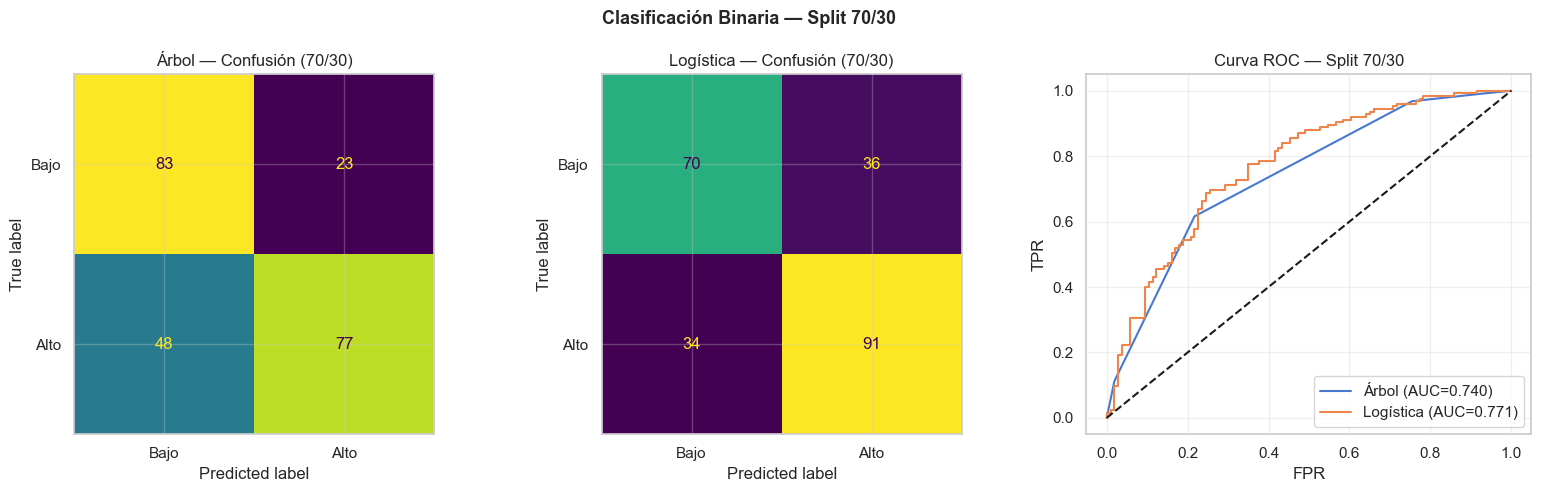

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test2, pred_arbol2),
    display_labels=['Bajo', 'Alto']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Árbol — Confusión (70/30)')

ConfusionMatrixDisplay(confusion_matrix(y_test2, pred_logit2),
    display_labels=['Bajo', 'Alto']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Logística — Confusión (70/30)')

fpr_a, tpr_a, _ = roc_curve(y_test2, prob_arbol2)
fpr_l, tpr_l, _ = roc_curve(y_test2, prob_logit2)
axes[2].plot(fpr_a, tpr_a, label=f"Árbol (AUC={roc_auc_score(y_test2, prob_arbol2):.3f})")
axes[2].plot(fpr_l, tpr_l, label=f"Logística (AUC={roc_auc_score(y_test2, prob_logit2):.3f})")
axes[2].plot([0,1],[0,1],'k--')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('Curva ROC — Split 70/30'); axes[2].legend()

plt.suptitle('Clasificación Binaria — Split 70/30', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/clasif_split2.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Split 3 — 60/40

In [9]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y)

X_train3_sc = scaler.fit_transform(X_train3)
X_test3_sc  = scaler.transform(X_test3)

arbol3 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=15, min_samples_split=20, class_weight="balanced", random_state=42)
arbol3.fit(X_train3, y_train3)
pred_arbol3 = arbol3.predict(X_test3)
prob_arbol3 = arbol3.predict_proba(X_test3)[:, 1]

logit3 = LogisticRegression(max_iter=1000, random_state=42)
logit3.fit(X_train3_sc, y_train3)
pred_logit3 = logit3.predict(X_test3_sc)
prob_logit3 = logit3.predict_proba(X_test3_sc)[:, 1]

resultados.append(metricas_clasificacion(y_test3, pred_arbol3, prob_arbol3, "60/40", "Árbol"))
resultados.append(metricas_clasificacion(y_test3, pred_logit3, prob_logit3, "60/40", "Reg. Logística"))

print("=== Split 60/40 ===")
print("\n--- Árbol de Clasificación ---")
print(classification_report(y_test3, pred_arbol3,
      target_names=['Rating bajo', 'Rating alto']))
print("\n--- Regresión Logística ---")
print(classification_report(y_test3, pred_logit3,
      target_names=['Rating bajo', 'Rating alto']))

=== Split 60/40 ===

--- Árbol de Clasificación ---
              precision    recall  f1-score   support

 Rating bajo       0.61      0.76      0.68       142
 Rating alto       0.74      0.58      0.65       166

    accuracy                           0.66       308
   macro avg       0.67      0.67      0.66       308
weighted avg       0.68      0.66      0.66       308


--- Regresión Logística ---
              precision    recall  f1-score   support

 Rating bajo       0.67      0.64      0.65       142
 Rating alto       0.70      0.73      0.72       166

    accuracy                           0.69       308
   macro avg       0.69      0.68      0.69       308
weighted avg       0.69      0.69      0.69       308



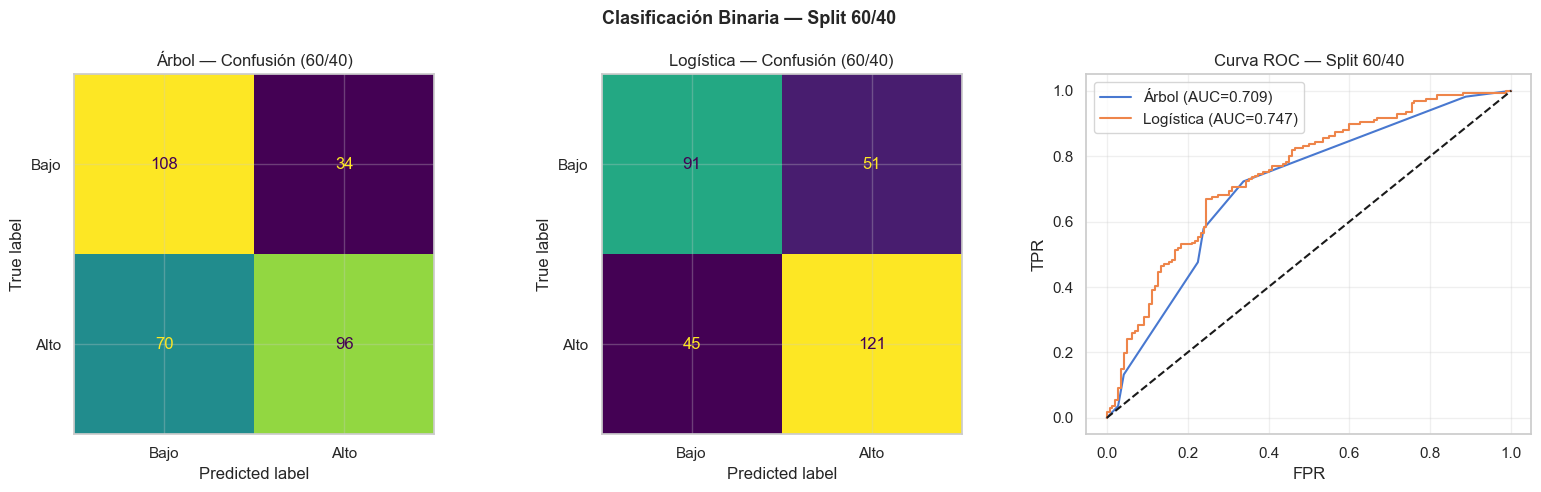

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test3, pred_arbol3),
    display_labels=['Bajo', 'Alto']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Árbol — Confusión (60/40)')

ConfusionMatrixDisplay(confusion_matrix(y_test3, pred_logit3),
    display_labels=['Bajo', 'Alto']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Logística — Confusión (60/40)')

fpr_a, tpr_a, _ = roc_curve(y_test3, prob_arbol3)
fpr_l, tpr_l, _ = roc_curve(y_test3, prob_logit3)
axes[2].plot(fpr_a, tpr_a, label=f"Árbol (AUC={roc_auc_score(y_test3, prob_arbol3):.3f})")
axes[2].plot(fpr_l, tpr_l, label=f"Logística (AUC={roc_auc_score(y_test3, prob_logit3):.3f})")
axes[2].plot([0,1],[0,1],'k--')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('Curva ROC — Split 60/40'); axes[2].legend()

plt.suptitle('Clasificación Binaria — Split 60/40', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/clasif_split3.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Visualización del árbol de clasificación

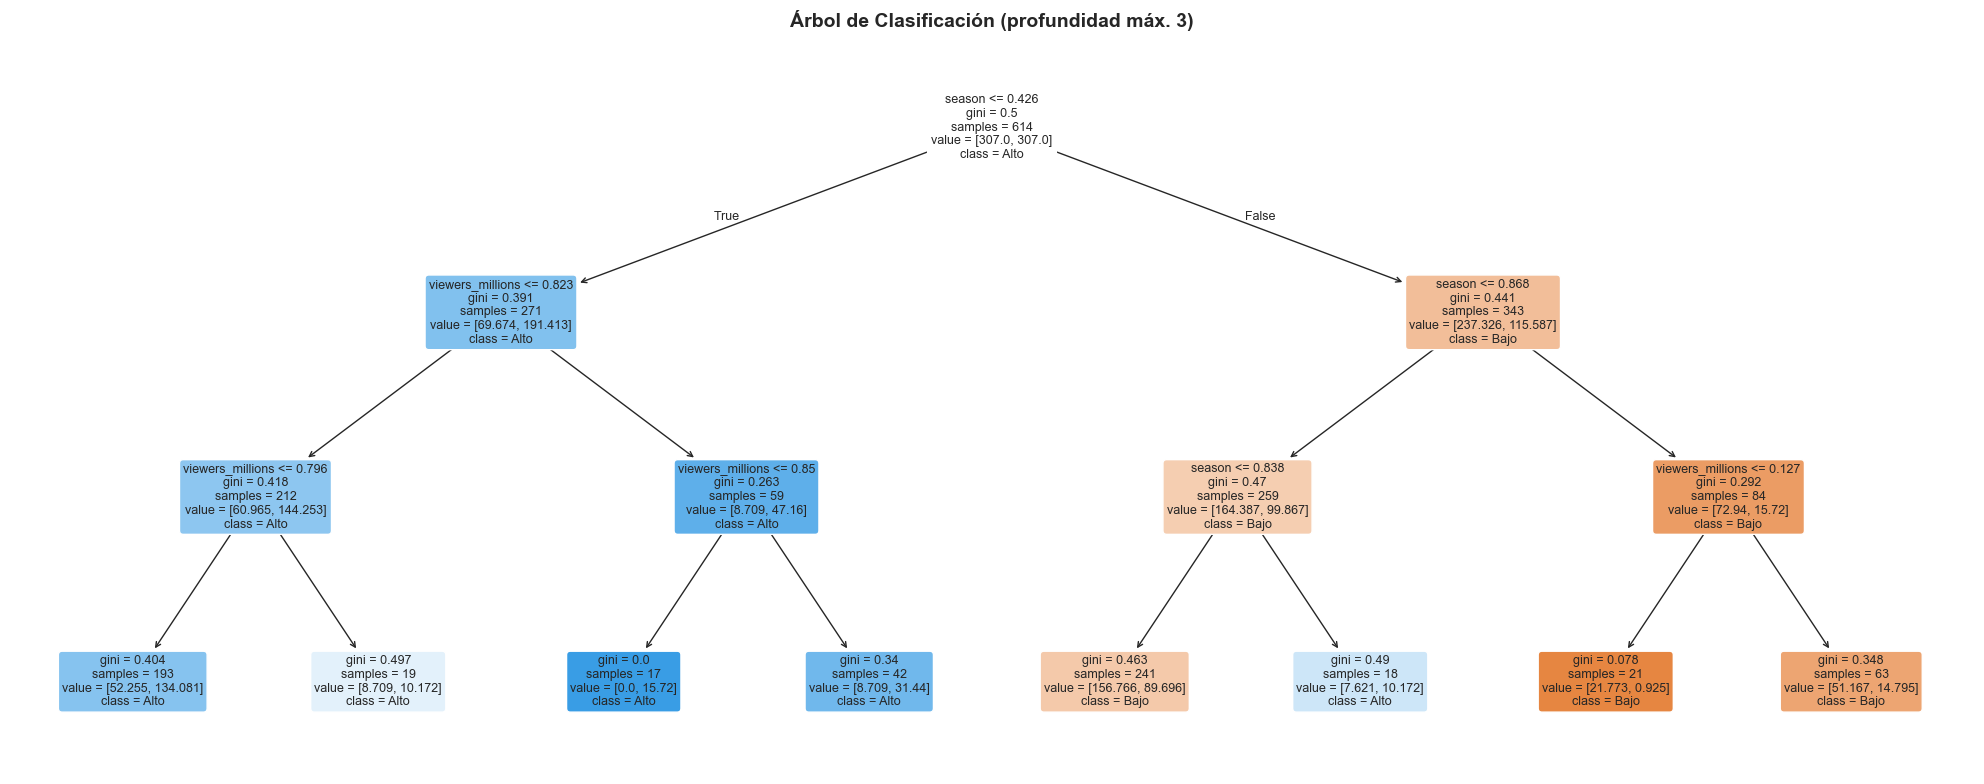


Reglas del árbol (primeros 3 niveles):
|--- season <= 0.43
|   |--- viewers_millions <= 0.82
|   |   |--- viewers_millions <= 0.80
|   |   |   |--- class: 1
|   |   |--- viewers_millions >  0.80
|   |   |   |--- class: 1
|   |--- viewers_millions >  0.82
|   |   |--- viewers_millions <= 0.85
|   |   |   |--- class: 1
|   |   |--- viewers_millions >  0.85
|   |   |   |--- class: 1
|--- season >  0.43
|   |--- season <= 0.87
|   |   |--- season <= 0.84
|   |   |   |--- class: 0
|   |   |--- season >  0.84
|   |   |   |--- class: 1
|   |--- season >  0.87
|   |   |--- viewers_millions <= 0.13
|   |   |   |--- class: 0
|   |   |--- viewers_millions >  0.13
|   |   |   |--- class: 0



In [11]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(arbol1, feature_names=FEATURES,
          class_names=['Bajo', 'Alto'],
          filled=True, rounded=True, max_depth=3, ax=ax, fontsize=9)
plt.title("Árbol de Clasificación (profundidad máx. 3)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/arbol_clasif_visualizacion.png", dpi=120, bbox_inches='tight')
plt.show()

print("\nReglas del árbol (primeros 3 niveles):")
print(export_text(arbol1, feature_names=FEATURES, max_depth=3))

## 7. Coeficientes de la Regresión Logística

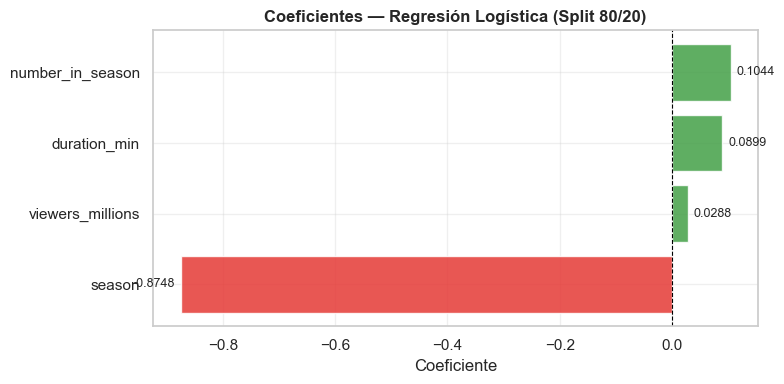

In [12]:
coef_df = pd.DataFrame({
    "Variable": FEATURES,
    "Coeficiente": logit1.coef_[0]
}).sort_values("Coeficiente")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#E53935' if v < 0 else '#43A047' for v in coef_df["Coeficiente"]]
ax.barh(coef_df["Variable"], coef_df["Coeficiente"], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("Coeficiente")
ax.set_title("Coeficientes — Regresión Logística (Split 80/20)", fontweight='bold')
for i, v in enumerate(coef_df["Coeficiente"]):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f"{v:.4f}",
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/logit_coeficientes.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. SUMMARY — Tabla comparativa de todos los modelos y splits


  SUMMARY — CLASIFICACIÓN BINARIA (Árbol + Regresión Logística)
        Modelo Split  Accuracy  Precision  Recall     F1  ROC-AUC
         Árbol 80/20    0.6753     0.7391  0.6145 0.6711   0.7263
Reg. Logística 80/20    0.7013     0.7229  0.7229 0.7229   0.7819
         Árbol 70/30    0.6926     0.7700  0.6160 0.6844   0.7405
Reg. Logística 70/30    0.6970     0.7165  0.7280 0.7222   0.7707
         Árbol 60/40    0.6623     0.7385  0.5783 0.6486   0.7088
Reg. Logística 60/40    0.6883     0.7035  0.7289 0.7160   0.7466

Árbol:
  Mejor Accuracy : 0.6926 (Split 70/30)
  Mejor F1       : 0.6844 (Split 70/30)
  Mejor ROC-AUC  : 0.7405 (Split 70/30)

Reg. Logística:
  Mejor Accuracy : 0.7013 (Split 80/20)
  Mejor F1       : 0.7229 (Split 80/20)
  Mejor ROC-AUC  : 0.7819 (Split 80/20)


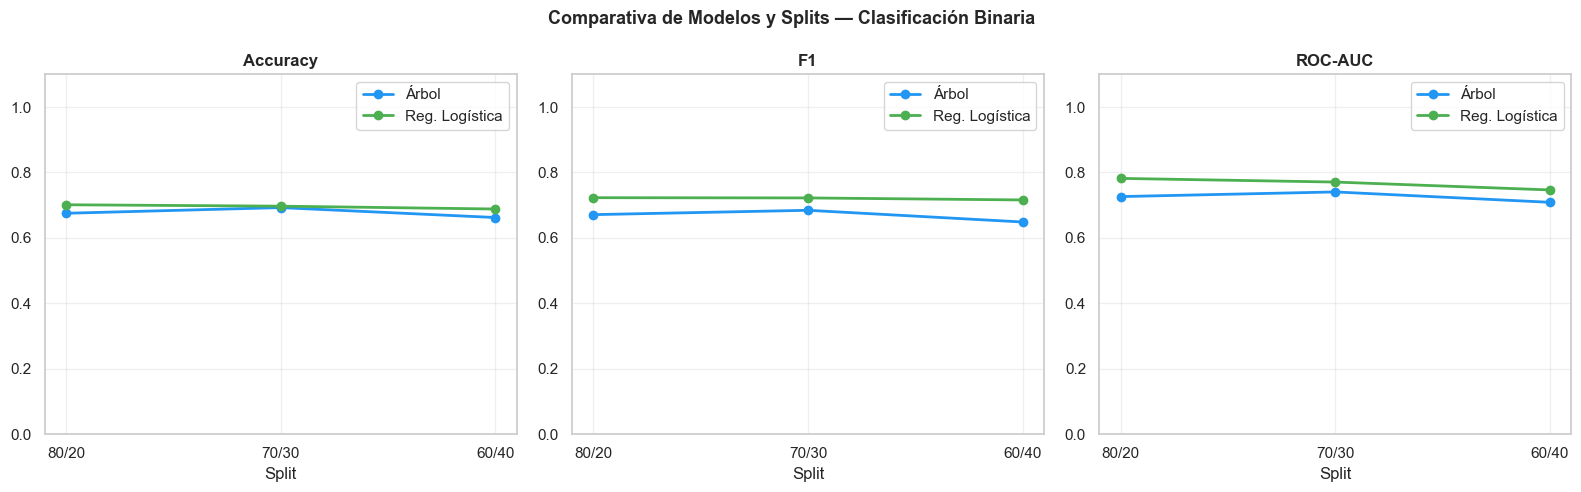

,Modelo,Split,Accuracy,Precision,Recall,F1,ROC-AUC
0,Árbol,80/20,0.6753,0.7391,0.6145,0.6711,0.7263
1,Reg. Logística,80/20,0.7013,0.7229,0.7229,0.7229,0.7819
2,Árbol,70/30,0.6926,0.7700,0.6160,0.6844,0.7405
3,Reg. Logística,70/30,0.6970,0.7165,0.7280,0.7222,0.7707
4,Árbol,60/40,0.6623,0.7385,0.5783,0.6486,0.7088
5,Reg. Logística,60/40,0.6883,0.7035,0.7289,0.7160,0.7466


In [13]:
df_res = pd.DataFrame(resultados)

print("\n" + "="*75)
print("  SUMMARY — CLASIFICACIÓN BINARIA (Árbol + Regresión Logística)")
print("="*75)
print(df_res.to_string(index=False))
print("="*75)

for modelo in ["Árbol", "Reg. Logística"]:
    sub = df_res[df_res["Modelo"] == modelo]
    print(f"\n{modelo}:")
    print(f"  Mejor Accuracy : {sub['Accuracy'].max():.4f} (Split {sub.loc[sub['Accuracy'].idxmax(), 'Split']})")
    print(f"  Mejor F1       : {sub['F1'].max():.4f} (Split {sub.loc[sub['F1'].idxmax(), 'Split']})")
    print(f"  Mejor ROC-AUC  : {sub['ROC-AUC'].max():.4f} (Split {sub.loc[sub['ROC-AUC'].idxmax(), 'Split']})")

# Gráfica comparativa
metricas_plot = ["Accuracy", "F1", "ROC-AUC"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores_modelo = {"Árbol": "#2196F3", "Reg. Logística": "#4CAF50"}

for ax, met in zip(axes, metricas_plot):
    for modelo, color in colores_modelo.items():
        sub = df_res[df_res["Modelo"] == modelo]
        ax.plot(sub["Split"], sub[met], marker='o', label=modelo, color=color, linewidth=2)
    ax.set_title(met, fontweight='bold')
    ax.set_xlabel("Split")
    ax.set_ylim(0, 1.1)
    ax.legend()

plt.suptitle("Comparativa de Modelos y Splits — Clasificación Binaria",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/clasif_summary.png", dpi=150, bbox_inches='tight')
plt.show()

df_res